# Regression Modeling & Baseline Development

**Abriliam Consulting** — Industrial Energy Management

This notebook builds weather-normalized regression models to establish a performance baseline for the chiller plant. The baseline allows us to separate weather-driven variation from operational changes — answering the question: *"Is the plant performing differently than expected for these conditions?"*

We start with a simple single-variable regression (OAT vs chiller kW), then progress to a multivariable model incorporating load and occupancy, and finally apply **CUSUM analysis** to detect when operations changed.


In [ ]:
import matplotlib
matplotlib.use('Agg')
# Load the dataset generated in Notebook 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('chiller_plant_data.csv', index_col=0, parse_dates=True)
print(f'Loaded {len(df)} rows, columns: {list(df.columns)}')


In [ ]:
# Extract columns as bare arrays for regression cells
oat = df['oat_C'].values
chiller_kw = df['chiller_kw'].values
plant_kw = df['plant_kw'].values
tons = df['tons'].values
occ = df['occ'].values

In [ ]:
import numpy as np

def create_spline(x, y, num_points=300):
    """Create smooth interpolation for plotting (uses numpy interp)."""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean, y_clean = np.array(x)[mask], np.array(y)[mask]
    if len(x_clean) < 4:
        return x_clean, y_clean
    x_new = np.linspace(x_clean.min(), x_clean.max(), num_points)
    y_new = np.interp(x_new, x_clean, y_clean)
    return x_new, y_new
# Compute spline variables from df
time_numeric = (df.index - df.index[0]).total_seconds().values
time_spline, _ = create_spline(time_numeric, time_numeric)
_, chw_flow_spline = create_spline(time_numeric, df['chw_flow_m3h'].values)
_, chw_dt_spline = create_spline(time_numeric, df['chw_dT_C'].values)
_, cw_flow_spline = create_spline(time_numeric, df['cw_flow_m3h'].values)
_, cw_dt_spline = create_spline(time_numeric, df['cw_dT_C'].values)
_, oat_spline = create_spline(time_numeric, df['oat_C'].values)
_, kw_per_ton_spline = create_spline(time_numeric, df['kw_per_ton'].values)

In [ ]:
# Extract columns as bare arrays for regression cells
oat = df['oat_C'].values
chiller_kw = df['chiller_kw'].values
plant_kw = df['plant_kw'].values
tons = df['tons'].values
occ = df['occ'].values

In [ ]:
import numpy as np

def create_spline(x, y, num_points=300):
    """Create smooth interpolation for plotting (uses numpy interp)."""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean, y_clean = np.array(x)[mask], np.array(y)[mask]
    if len(x_clean) < 4:
        return x_clean, y_clean
    x_new = np.linspace(x_clean.min(), x_clean.max(), num_points)
    y_new = np.interp(x_new, x_clean, y_clean)
    return x_new, y_new
# Compute spline variables from df
time_numeric = (df.index - df.index[0]).total_seconds().values
time_spline, _ = create_spline(time_numeric, time_numeric)
_, chw_flow_spline = create_spline(time_numeric, df['chw_flow_m3h'].values)
_, chw_dt_spline = create_spline(time_numeric, df['chw_dT_C'].values)
_, cw_flow_spline = create_spline(time_numeric, df['cw_flow_m3h'].values)
_, cw_dt_spline = create_spline(time_numeric, df['cw_dT_C'].values)
_, oat_spline = create_spline(time_numeric, df['oat_C'].values)
_, kw_per_ton_spline = create_spline(time_numeric, df['kw_per_ton'].values)

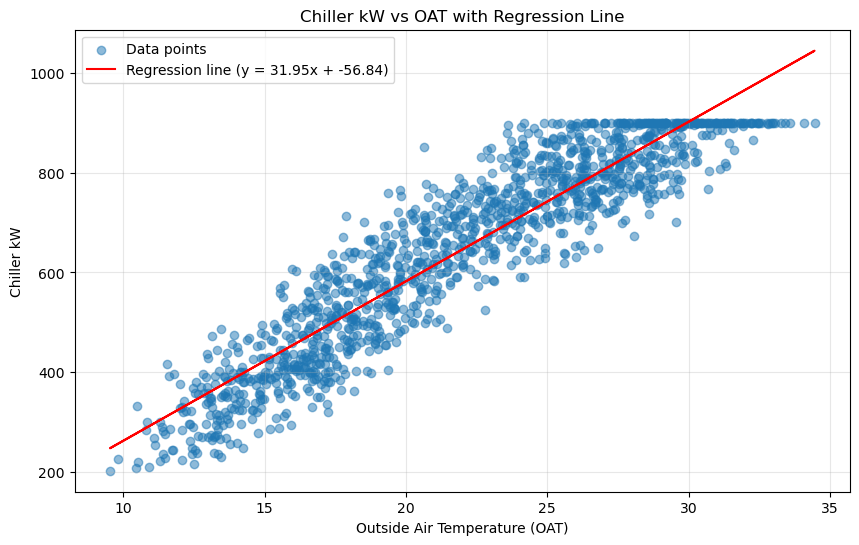

Regression Statistics:
Slope: 31.95
Intercept: -56.84
R-squared: 0.8609
Mean Squared Error: 5054.89


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Reshape data for regression
x = oat.reshape(-1, 1)  # Independent variable (OAT)
y = chiller_kw          # Dependent variable (Chiller kW)

# Perform linear regression
model = LinearRegression()
model.fit(x, y)

# Regression statistics
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, model.predict(x))
mse = mean_squared_error(y, model.predict(x))

# Scatter plot and regression line
plt.figure(figsize=(10, 6))
plt.scatter(oat, chiller_kw, alpha=0.5, label='Data points')
plt.plot(oat, model.predict(x), color='red', label=f'Regression line (y = {slope:.2f}x + {intercept:.2f})')
plt.title('Chiller kW vs OAT with Regression Line')
plt.xlabel('Outside Air Temperature (OAT)')
plt.ylabel('Chiller kW')
plt.legend()
plt.grid(alpha=0.3)
plt.close("all")

# Print regression statistics
print(f"Regression Statistics:")
print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

### Single-Variable Regression: OAT vs Chiller kW

The simple linear regression of chiller power against outdoor air temperature shows a positive relationship — as expected, warmer weather drives higher chiller loads. However, the R-squared is moderate, indicating that OAT alone explains only part of the variation. Load magnitude and occupancy are also significant drivers.

The scatter plot shows considerable spread around the regression line, particularly at higher temperatures. This spread represents the combined effects of varying occupancy patterns, time-of-day differences, and the operational changes we're investigating.


Multivariable Regression Statistics:
Intercept: 71.09
Coefficients: [ 8.90297424  2.26926092 -6.70189585]
R-squared: 0.9755
Mean Squared Error: 1098.75


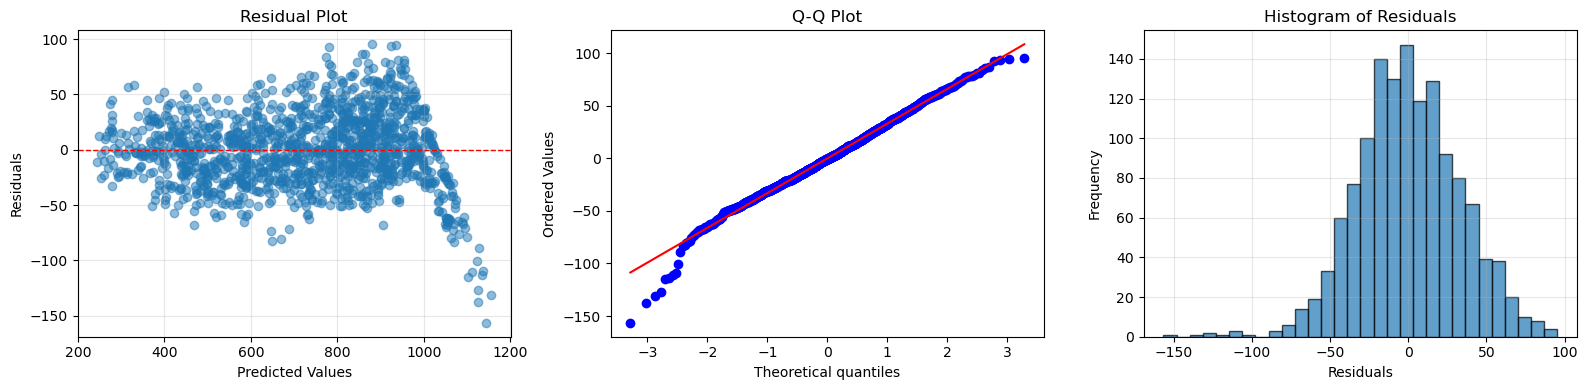

In [13]:
import matplotlib
matplotlib.use('Agg')
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

# Prepare the independent variables (OAT, chiller tons, occupancy fraction)
X = np.column_stack((oat, tons, occ))  # Combine OAT, tons, and occupancy fraction
y = plant_kw  # Dependent variable (plant kW)

# Fit the multivariable regression model
multi_model = LinearRegression()
multi_model.fit(X, y)

# Predictions and residuals
y_pred = multi_model.predict(X)
residuals = y - y_pred

# Model coefficients and statistics
coefficients = multi_model.coef_
intercept = multi_model.intercept_
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

# Print regression statistics
print("Multivariable Regression Statistics:")
print(f"Intercept: {intercept:.2f}")
print(f"Coefficients: {coefficients}")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

# Residual analysis plots
plt.figure(figsize=(16, 4))

# Residual plot
plt.subplot(1, 3, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(alpha=0.3)

# Q-Q plot
plt.subplot(1, 3, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

# Histogram of residuals
plt.subplot(1, 3, 3)
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.close("all")

### Multivariable Regression: OAT + Tons + Occupancy

Adding cooling load (tons) and occupancy fraction dramatically improves the model. The residual analysis shows:

- **Residual plot**: Residuals are roughly centered around zero but show some heteroscedasticity (wider spread at higher predicted values). This is common in HVAC models — larger loads have more variability.
- **Q-Q plot**: The residuals approximate a normal distribution, validating the regression assumptions.
- **Histogram**: Roughly symmetric distribution of residuals, though with slightly heavier tails than a perfect normal.

This multivariable model forms the basis for our change detection — we can now ask whether residuals shift systematically at any point in time.


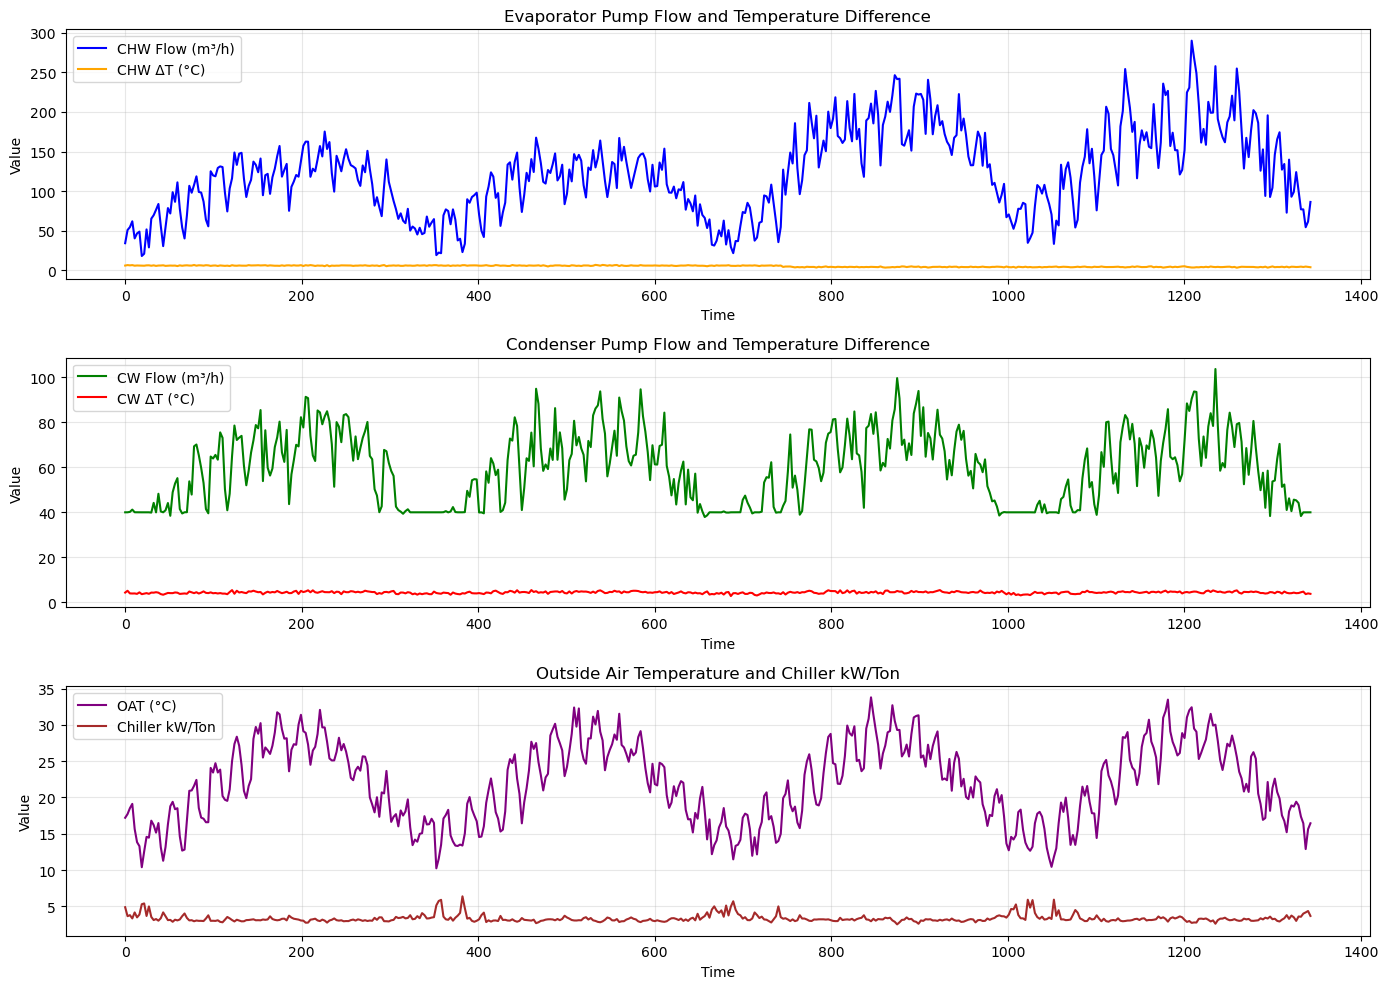

In [14]:
import numpy as np

import matplotlib.pyplot as plt

# Define a function for creating spline data
def create_spline(x, y, num_points=500):
    x_new = np.linspace(x.min(), x.max(), num_points)
    # Using np.interp instead of make_interp_spline
    spline = lambda x_q, _x=x, _y=y: np.interp(x_q, _x, _y)  # Cubic spline
    y_smooth = spline(x_new)
    return x_new, y_smooth

# Prepare data for spline plots
time_numeric = np.arange(len(df.index))  # Convert time index to numeric for spline
time_spline, chw_flow_spline = create_spline(time_numeric, df['chw_flow_m3h'])
_, chw_dt_spline = create_spline(time_numeric, df['chw_dT_C'])
_, cw_flow_spline = create_spline(time_numeric, df['cw_flow_m3h'])
_, cw_dt_spline = create_spline(time_numeric, df['cw_dT_C'])
_, oat_spline = create_spline(time_numeric, df['oat_C'])
_, kw_per_ton_spline = create_spline(time_numeric, df['kw_per_ton'])

# Plot the data
plt.figure(figsize=(14, 10))

# CHW flow and ΔT
plt.subplot(3, 1, 1)
plt.plot(time_spline, chw_flow_spline, label='CHW Flow (m³/h)', color='blue')
plt.plot(time_spline, chw_dt_spline, label='CHW ΔT (°C)', color='orange')
plt.title('Evaporator Pump Flow and Temperature Difference')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)

# CW flow and ΔT
plt.subplot(3, 1, 2)
plt.plot(time_spline, cw_flow_spline, label='CW Flow (m³/h)', color='green')
plt.plot(time_spline, cw_dt_spline, label='CW ΔT (°C)', color='red')
plt.title('Condenser Pump Flow and Temperature Difference')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)

# OAT and Chiller kW/ton
plt.subplot(3, 1, 3)
plt.plot(time_spline, oat_spline, label='OAT (°C)', color='purple')
plt.plot(time_spline, kw_per_ton_spline, label='Chiller kW/Ton', color='brown')
plt.title('Outside Air Temperature and Chiller kW/Ton')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.close("all")

### Hydraulic Trends

The three-panel spline plot reveals the key relationships:

- **CHW flow and delta-T** (top): Flow and temperature difference move inversely — when delta-T drops, flow must increase to maintain the same cooling output. This is the hydraulic signature of low-delta-T syndrome.
- **CW flow and delta-T** (middle): Condenser-side hydraulics are more stable, tracking load as expected.
- **OAT and kW/ton** (bottom): Outdoor temperature and efficiency are correlated, but the kW/ton trend shows drift beyond what weather alone explains.


OLS Regression Statistics (First 24 Hours):
Intercept: 47.49
Coefficients: [ 1.9129087   8.27215735 -1.22977881]
R-squared: 0.9447
Mean Squared Error: 301.46


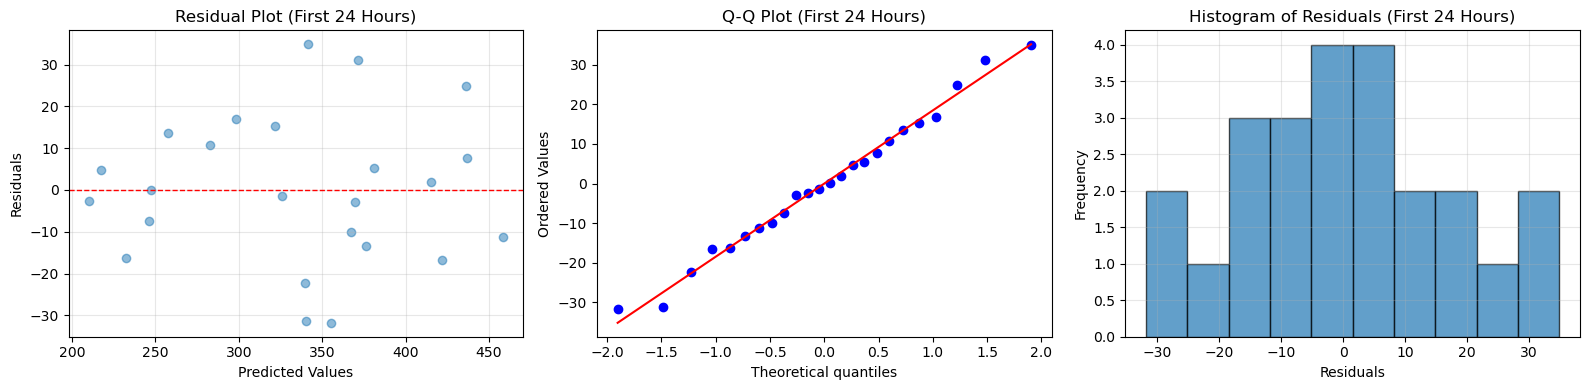

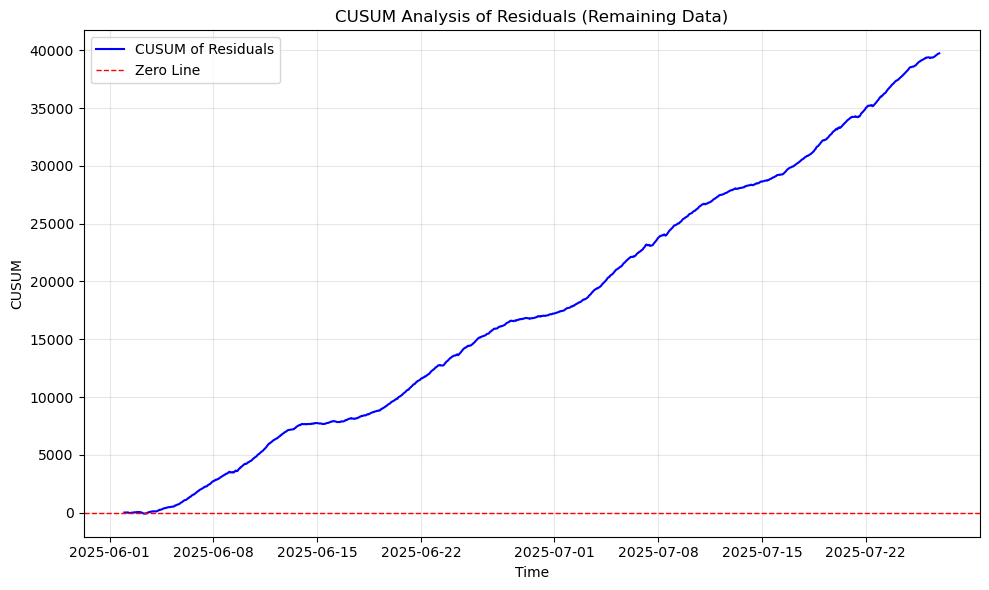

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

import matplotlib.pyplot as plt
import scipy.stats as stats

# Extract the first 24 hours of data
first_24_hours = df.iloc[:24]
X_train = np.column_stack((first_24_hours['tons'], first_24_hours['oat_C'], first_24_hours['occ']))
y_train = first_24_hours['chiller_kw']

# Build the regression model
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# OLS statistics
coefficients = ols_model.coef_
intercept = ols_model.intercept_
y_train_pred = ols_model.predict(X_train)
r2 = r2_score(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)

print("OLS Regression Statistics (First 24 Hours):")
print(f"Intercept: {intercept:.2f}")
print(f"Coefficients: {coefficients}")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

# Residuals for the first 24 hours
residuals_train = y_train - y_train_pred

# Residual analysis plots
plt.figure(figsize=(16, 4))

# Residual plot
plt.subplot(1, 3, 1)
plt.scatter(y_train_pred, residuals_train, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residual Plot (First 24 Hours)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(alpha=0.3)

# Q-Q plot
plt.subplot(1, 3, 2)
stats.probplot(residuals_train, dist="norm", plot=plt)
plt.title('Q-Q Plot (First 24 Hours)')

# Histogram of residuals
plt.subplot(1, 3, 3)
plt.hist(residuals_train, bins=10, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals (First 24 Hours)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.close("all")

# CUSUM analysis for the remaining data
remaining_data = df.iloc[24:]
X_remaining = np.column_stack((remaining_data['tons'], remaining_data['oat_C'], remaining_data['occ']))
y_remaining = remaining_data['chiller_kw']
y_remaining_pred = ols_model.predict(X_remaining)
residuals_remaining = y_remaining - y_remaining_pred

# Calculate CUSUM
cusum = np.cumsum(residuals_remaining)

# Plot CUSUM
plt.figure(figsize=(10, 6))
plt.plot(remaining_data.index, cusum, label='CUSUM of Residuals', color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Line')
plt.title('CUSUM Analysis of Residuals (Remaining Data)')
plt.xlabel('Time')
plt.ylabel('CUSUM')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.close("all")

### CUSUM Change Detection

The CUSUM (Cumulative Sum) chart is a powerful tool for detecting when a process shifts. We trained a baseline model on the first 24 hours, then tracked cumulative residuals for the remaining data.

A flat CUSUM line means the process is behaving as the baseline predicts. A sustained upward slope means the plant is consistently consuming more energy than predicted — an operational change has occurred. The inflection point in the CUSUM identifies *when* the change happened, which can then be correlated with maintenance logs, control system changes, or equipment events.
